# About this notebook
This notebook contains all the code for the main experiment of project assigment 2 as well as answers, explanations, code, etc for the EXercise 2.14.

# utils.py
The following code cell is unchanged form the Berkley AIMA repository (https://github.com/aimacode/aima-python)


In [1]:
"""Provides some utilities widely used by other modules"""

import bisect
import collections
import collections.abc
import functools
import heapq
import operator
import os.path
import random
from itertools import chain, combinations
from statistics import mean

import numpy as np


# ______________________________________________________________________________
# Functions on Sequences and Iterables


def sequence(iterable):
    """Converts iterable to sequence, if it is not already one."""
    return iterable if isinstance(iterable, collections.abc.Sequence) else tuple([iterable])


def remove_all(item, seq):
    """Return a copy of seq (or string) with all occurrences of item removed."""
    if isinstance(seq, str):
        return seq.replace(item, '')
    elif isinstance(seq, set):
        rest = seq.copy()
        rest.remove(item)
        return rest
    else:
        return [x for x in seq if x != item]


def unique(seq):
    """Remove duplicate elements from seq. Assumes hashable elements."""
    return list(set(seq))


def count(seq):
    """Count the number of items in sequence that are interpreted as true."""
    return sum(map(bool, seq))


def multimap(items):
    """Given (key, val) pairs, return {key: [val, ....], ...}."""
    result = collections.defaultdict(list)
    for (key, val) in items:
        result[key].append(val)
    return dict(result)


def multimap_items(mmap):
    """Yield all (key, val) pairs stored in the multimap."""
    for (key, vals) in mmap.items():
        for val in vals:
            yield key, val


def product(numbers):
    """Return the product of the numbers, e.g. product([2, 3, 10]) == 60"""
    result = 1
    for x in numbers:
        result *= x
    return result


def first(iterable, default=None):
    """Return the first element of an iterable; or default."""
    return next(iter(iterable), default)


def is_in(elt, seq):
    """Similar to (elt in seq), but compares with 'is', not '=='."""
    return any(x is elt for x in seq)


def mode(data):
    """Return the most common data item. If there are ties, return any one of them."""
    [(item, count)] = collections.Counter(data).most_common(1)
    return item


def power_set(iterable):
    """power_set([1,2,3]) --> (1,) (2,) (3,) (1,2) (1,3) (2,3) (1,2,3)"""
    s = list(iterable)
    return list(chain.from_iterable(combinations(s, r) for r in range(len(s) + 1)))[1:]


def extend(s, var, val):
    """Copy dict s and extend it by setting var to val; return copy."""
    return {**s, var: val}


def flatten(seqs):
    return sum(seqs, [])


# ______________________________________________________________________________
# argmin and argmax

identity = lambda x: x


def argmin_random_tie(seq, key=identity):
    """Return a minimum element of seq; break ties at random."""
    return min(shuffled(seq), key=key)


def argmax_random_tie(seq, key=identity):
    """Return an element with highest fn(seq[i]) score; break ties at random."""
    return max(shuffled(seq), key=key)


def shuffled(iterable):
    """Randomly shuffle a copy of iterable."""
    items = list(iterable)
    random.shuffle(items)
    return items


# ______________________________________________________________________________
# Statistical and mathematical functions


def histogram(values, mode=0, bin_function=None):
    """Return a list of (value, count) pairs, summarizing the input values.
    Sorted by increasing value, or if mode=1, by decreasing count.
    If bin_function is given, map it over values first."""
    if bin_function:
        values = map(bin_function, values)

    bins = {}
    for val in values:
        bins[val] = bins.get(val, 0) + 1

    if mode:
        return sorted(list(bins.items()), key=lambda x: (x[1], x[0]), reverse=True)
    else:
        return sorted(bins.items())


def dot_product(x, y):
    """Return the sum of the element-wise product of vectors x and y."""
    return sum(_x * _y for _x, _y in zip(x, y))


def element_wise_product(x, y):
    """Return vector as an element-wise product of vectors x and y."""
    assert len(x) == len(y)
    return np.multiply(x, y)


def matrix_multiplication(x, *y):
    """Return a matrix as a matrix-multiplication of x and arbitrary number of matrices *y."""

    result = x
    for _y in y:
        result = np.matmul(result, _y)

    return result


def vector_add(a, b):
    """Component-wise addition of two vectors."""
    return tuple(map(operator.add, a, b))


def scalar_vector_product(x, y):
    """Return vector as a product of a scalar and a vector"""
    return np.multiply(x, y)


def probability(p):
    """Return true with probability p."""
    return p > random.uniform(0.0, 1.0)


def weighted_sample_with_replacement(n, seq, weights):
    """Pick n samples from seq at random, with replacement, with the
    probability of each element in proportion to its corresponding
    weight."""
    sample = weighted_sampler(seq, weights)
    return [sample() for _ in range(n)]


def weighted_sampler(seq, weights):
    """Return a random-sample function that picks from seq weighted by weights."""
    totals = []
    for w in weights:
        totals.append(w + totals[-1] if totals else w)
    return lambda: seq[bisect.bisect(totals, random.uniform(0, totals[-1]))]


def weighted_choice(choices):
    """A weighted version of random.choice"""
    # NOTE: should be replaced by random.choices if we port to Python 3.6

    total = sum(w for _, w in choices)
    r = random.uniform(0, total)
    upto = 0
    for c, w in choices:
        if upto + w >= r:
            return c, w
        upto += w


def rounder(numbers, d=4):
    """Round a single number, or sequence of numbers, to d decimal places."""
    if isinstance(numbers, (int, float)):
        return round(numbers, d)
    else:
        constructor = type(numbers)  # Can be list, set, tuple, etc.
        return constructor(rounder(n, d) for n in numbers)


def num_or_str(x):  # TODO: rename as `atom`
    """The argument is a string; convert to a number if possible, or strip it."""
    try:
        return int(x)
    except ValueError:
        try:
            return float(x)
        except ValueError:
            return str(x).strip()


def euclidean_distance(x, y):
    return np.sqrt(sum((_x - _y) ** 2 for _x, _y in zip(x, y)))


def manhattan_distance(x, y):
    return sum(abs(_x - _y) for _x, _y in zip(x, y))


def hamming_distance(x, y):
    return sum(_x != _y for _x, _y in zip(x, y))


def cross_entropy_loss(x, y):
    return (-1.0 / len(x)) * sum(_x * np.log(_y) + (1 - _x) * np.log(1 - _y) for _x, _y in zip(x, y))


def mean_squared_error_loss(x, y):
    return (1.0 / len(x)) * sum((_x - _y) ** 2 for _x, _y in zip(x, y))


def rms_error(x, y):
    return np.sqrt(ms_error(x, y))


def ms_error(x, y):
    return mean((_x - _y) ** 2 for _x, _y in zip(x, y))


def mean_error(x, y):
    return mean(abs(_x - _y) for _x, _y in zip(x, y))


def mean_boolean_error(x, y):
    return mean(_x != _y for _x, _y in zip(x, y))


def normalize(dist):
    """Multiply each number by a constant such that the sum is 1.0"""
    if isinstance(dist, dict):
        total = sum(dist.values())
        for key in dist:
            dist[key] = dist[key] / total
            assert 0 <= dist[key] <= 1  # probabilities must be between 0 and 1
        return dist
    total = sum(dist)
    return [(n / total) for n in dist]


def random_weights(min_value, max_value, num_weights):
    return [random.uniform(min_value, max_value) for _ in range(num_weights)]


def sigmoid(x):
    """Return activation value of x with sigmoid function."""
    return 1 / (1 + np.exp(-x))


def sigmoid_derivative(value):
    return value * (1 - value)


def elu(x, alpha=0.01):
    return x if x > 0 else alpha * (np.exp(x) - 1)


def elu_derivative(value, alpha=0.01):
    return 1 if value > 0 else alpha * np.exp(value)


def tanh(x):
    return np.tanh(x)


def tanh_derivative(value):
    return 1 - (value ** 2)


def leaky_relu(x, alpha=0.01):
    return x if x > 0 else alpha * x


def leaky_relu_derivative(value, alpha=0.01):
    return 1 if value > 0 else alpha


def relu(x):
    return max(0, x)


def relu_derivative(value):
    return 1 if value > 0 else 0


def step(x):
    """Return activation value of x with sign function"""
    return 1 if x >= 0 else 0


def gaussian(mean, st_dev, x):
    """Given the mean and standard deviation of a distribution, it returns the probability of x."""
    return 1 / (np.sqrt(2 * np.pi) * st_dev) * np.e ** (-0.5 * (float(x - mean) / st_dev) ** 2)


def linear_kernel(x, y=None):
    if y is None:
        y = x
    return np.dot(x, y.T)


def polynomial_kernel(x, y=None, degree=2.0):
    if y is None:
        y = x
    return (1.0 + np.dot(x, y.T)) ** degree


def rbf_kernel(x, y=None, gamma=None):
    """Radial-basis function kernel (aka squared-exponential kernel)."""
    if y is None:
        y = x
    if gamma is None:
        gamma = 1.0 / x.shape[1]  # 1.0 / n_features
    return np.exp(-gamma * (-2.0 * np.dot(x, y.T) +
                            np.sum(x * x, axis=1).reshape((-1, 1)) + np.sum(y * y, axis=1).reshape((1, -1))))


# ______________________________________________________________________________
# Grid Functions


orientations = EAST, NORTH, WEST, SOUTH = [(1, 0), (0, 1), (-1, 0), (0, -1)]
turns = LEFT, RIGHT = (+1, -1)


def turn_heading(heading, inc, headings=orientations):
    return headings[(headings.index(heading) + inc) % len(headings)]


def turn_right(heading):
    return turn_heading(heading, RIGHT)


def turn_left(heading):
    return turn_heading(heading, LEFT)


def distance(a, b):
    """The distance between two (x, y) points."""
    xA, yA = a
    xB, yB = b
    return np.hypot((xA - xB), (yA - yB))


def distance_squared(a, b):
    """The square of the distance between two (x, y) points."""
    xA, yA = a
    xB, yB = b
    return (xA - xB) ** 2 + (yA - yB) ** 2


# ______________________________________________________________________________
# Misc Functions

class injection:
    """Dependency injection of temporary values for global functions/classes/etc.
    E.g., `with injection(DataBase=MockDataBase): ...`"""

    def __init__(self, **kwds):
        self.new = kwds

    def __enter__(self):
        self.old = {v: globals()[v] for v in self.new}
        globals().update(self.new)

    def __exit__(self, type, value, traceback):
        globals().update(self.old)


def memoize(fn, slot=None, maxsize=32):
    """Memoize fn: make it remember the computed value for any argument list.
    If slot is specified, store result in that slot of first argument.
    If slot is false, use lru_cache for caching the values."""
    if slot:
        def memoized_fn(obj, *args):
            if hasattr(obj, slot):
                return getattr(obj, slot)
            else:
                val = fn(obj, *args)
                setattr(obj, slot, val)
                return val
    else:
        @functools.lru_cache(maxsize=maxsize)
        def memoized_fn(*args):
            return fn(*args)

    return memoized_fn


def name(obj):
    """Try to find some reasonable name for the object."""
    return (getattr(obj, 'name', 0) or getattr(obj, '__name__', 0) or
            getattr(getattr(obj, '__class__', 0), '__name__', 0) or
            str(obj))


def isnumber(x):
    """Is x a number?"""
    return hasattr(x, '__int__')


def issequence(x):
    """Is x a sequence?"""
    return isinstance(x, collections.abc.Sequence)


def print_table(table, header=None, sep='   ', numfmt='{}'):
    """Print a list of lists as a table, so that columns line up nicely.
    header, if specified, will be printed as the first row.
    numfmt is the format for all numbers; you might want e.g. '{:.2f}'.
    (If you want different formats in different columns,
    don't use print_table.) sep is the separator between columns."""
    justs = ['rjust' if isnumber(x) else 'ljust' for x in table[0]]

    if header:
        table.insert(0, header)

    table = [[numfmt.format(x) if isnumber(x) else x for x in row]
             for row in table]

    sizes = list(map(lambda seq: max(map(len, seq)), list(zip(*[map(str, row) for row in table]))))

    for row in table:
        print(sep.join(getattr(str(x), j)(size) for (j, size, x) in zip(justs, sizes, row)))


def open_data(name, mode='r'):
    aima_root = os.path.dirname(__file__)
    aima_file = os.path.join(aima_root, *['aima-data', name])

    return open(aima_file, mode=mode)


def failure_test(algorithm, tests):
    """Grades the given algorithm based on how many tests it passes.
    Most algorithms have arbitrary output on correct execution, which is difficult
    to check for correctness. On the other hand, a lot of algorithms output something
    particular on fail (for example, False, or None).
    tests is a list with each element in the form: (values, failure_output)."""
    return mean(int(algorithm(x) != y) for x, y in tests)


# ______________________________________________________________________________
# Expressions

# See https://docs.python.org/3/reference/expressions.html#operator-precedence
# See https://docs.python.org/3/reference/datamodel.html#special-method-names

class Expr:
    """A mathematical expression with an operator and 0 or more arguments.
    op is a str like '+' or 'sin'; args are Expressions.
    Expr('x') or Symbol('x') creates a symbol (a nullary Expr).
    Expr('-', x) creates a unary; Expr('+', x, 1) creates a binary."""

    def __init__(self, op, *args):
        self.op = str(op)
        self.args = args

    # Operator overloads
    def __neg__(self):
        return Expr('-', self)

    def __pos__(self):
        return Expr('+', self)

    def __invert__(self):
        return Expr('~', self)

    def __add__(self, rhs):
        return Expr('+', self, rhs)

    def __sub__(self, rhs):
        return Expr('-', self, rhs)

    def __mul__(self, rhs):
        return Expr('*', self, rhs)

    def __pow__(self, rhs):
        return Expr('**', self, rhs)

    def __mod__(self, rhs):
        return Expr('%', self, rhs)

    def __and__(self, rhs):
        return Expr('&', self, rhs)

    def __xor__(self, rhs):
        return Expr('^', self, rhs)

    def __rshift__(self, rhs):
        return Expr('>>', self, rhs)

    def __lshift__(self, rhs):
        return Expr('<<', self, rhs)

    def __truediv__(self, rhs):
        return Expr('/', self, rhs)

    def __floordiv__(self, rhs):
        return Expr('//', self, rhs)

    def __matmul__(self, rhs):
        return Expr('@', self, rhs)

    def __or__(self, rhs):
        """Allow both P | Q, and P |'==>'| Q."""
        if isinstance(rhs, Expression):
            return Expr('|', self, rhs)
        else:
            return PartialExpr(rhs, self)

    # Reverse operator overloads
    def __radd__(self, lhs):
        return Expr('+', lhs, self)

    def __rsub__(self, lhs):
        return Expr('-', lhs, self)

    def __rmul__(self, lhs):
        return Expr('*', lhs, self)

    def __rdiv__(self, lhs):
        return Expr('/', lhs, self)

    def __rpow__(self, lhs):
        return Expr('**', lhs, self)

    def __rmod__(self, lhs):
        return Expr('%', lhs, self)

    def __rand__(self, lhs):
        return Expr('&', lhs, self)

    def __rxor__(self, lhs):
        return Expr('^', lhs, self)

    def __ror__(self, lhs):
        return Expr('|', lhs, self)

    def __rrshift__(self, lhs):
        return Expr('>>', lhs, self)

    def __rlshift__(self, lhs):
        return Expr('<<', lhs, self)

    def __rtruediv__(self, lhs):
        return Expr('/', lhs, self)

    def __rfloordiv__(self, lhs):
        return Expr('//', lhs, self)

    def __rmatmul__(self, lhs):
        return Expr('@', lhs, self)

    def __call__(self, *args):
        """Call: if 'f' is a Symbol, then f(0) == Expr('f', 0)."""
        if self.args:
            raise ValueError('Can only do a call for a Symbol, not an Expr')
        else:
            return Expr(self.op, *args)

    # Equality and repr
    def __eq__(self, other):
        """x == y' evaluates to True or False; does not build an Expr."""
        return isinstance(other, Expr) and self.op == other.op and self.args == other.args

    def __lt__(self, other):
        return isinstance(other, Expr) and str(self) < str(other)

    def __hash__(self):
        return hash(self.op) ^ hash(self.args)

    def __repr__(self):
        op = self.op
        args = [str(arg) for arg in self.args]
        if op.isidentifier():  # f(x) or f(x, y)
            return '{}({})'.format(op, ', '.join(args)) if args else op
        elif len(args) == 1:  # -x or -(x + 1)
            return op + args[0]
        else:  # (x - y)
            opp = (' ' + op + ' ')
            return '(' + opp.join(args) + ')'


# An 'Expression' is either an Expr or a Number.
# Symbol is not an explicit type; it is any Expr with 0 args.


Number = (int, float, complex)
Expression = (Expr, Number)


def Symbol(name):
    """A Symbol is just an Expr with no args."""
    return Expr(name)


def symbols(names):
    """Return a tuple of Symbols; names is a comma/whitespace delimited str."""
    return tuple(Symbol(name) for name in names.replace(',', ' ').split())


def subexpressions(x):
    """Yield the subexpressions of an Expression (including x itself)."""
    yield x
    if isinstance(x, Expr):
        for arg in x.args:
            yield from subexpressions(arg)


def arity(expression):
    """The number of sub-expressions in this expression."""
    if isinstance(expression, Expr):
        return len(expression.args)
    else:  # expression is a number
        return 0


# For operators that are not defined in Python, we allow new InfixOps:


class PartialExpr:
    """Given 'P |'==>'| Q, first form PartialExpr('==>', P), then combine with Q."""

    def __init__(self, op, lhs):
        self.op, self.lhs = op, lhs

    def __or__(self, rhs):
        return Expr(self.op, self.lhs, rhs)

    def __repr__(self):
        return "PartialExpr('{}', {})".format(self.op, self.lhs)


def expr(x):
    """Shortcut to create an Expression. x is a str in which:
    - identifiers are automatically defined as Symbols.
    - ==> is treated as an infix |'==>'|, as are <== and <=>.
    If x is already an Expression, it is returned unchanged. Example:
    >>> expr('P & Q ==> Q')
    ((P & Q) ==> Q)
    """
    return eval(expr_handle_infix_ops(x), defaultkeydict(Symbol)) if isinstance(x, str) else x


infix_ops = '==> <== <=>'.split()


def expr_handle_infix_ops(x):
    """Given a str, return a new str with ==> replaced by |'==>'|, etc.
    >>> expr_handle_infix_ops('P ==> Q')
    "P |'==>'| Q"
    """
    for op in infix_ops:
        x = x.replace(op, '|' + repr(op) + '|')
    return x


class defaultkeydict(collections.defaultdict):
    """Like defaultdict, but the default_factory is a function of the key.
    >>> d = defaultkeydict(len); d['four']
    4
    """

    def __missing__(self, key):
        self[key] = result = self.default_factory(key)
        return result


class hashabledict(dict):
    """Allows hashing by representing a dictionary as tuple of key:value pairs.
    May cause problems as the hash value may change during runtime."""

    def __hash__(self):
        return 1


# ______________________________________________________________________________
# Queues: Stack, FIFOQueue, PriorityQueue
# Stack and FIFOQueue are implemented as list and collection.deque
# PriorityQueue is implemented here


class PriorityQueue:
    """A Queue in which the minimum (or maximum) element (as determined by f and
    order) is returned first.
    If order is 'min', the item with minimum f(x) is
    returned first; if order is 'max', then it is the item with maximum f(x).
    Also supports dict-like lookup."""

    def __init__(self, order='min', f=lambda x: x):
        self.heap = []
        if order == 'min':
            self.f = f
        elif order == 'max':  # now item with max f(x)
            self.f = lambda x: -f(x)  # will be popped first
        else:
            raise ValueError("Order must be either 'min' or 'max'.")

    def append(self, item):
        """Insert item at its correct position."""
        heapq.heappush(self.heap, (self.f(item), item))

    def extend(self, items):
        """Insert each item in items at its correct position."""
        for item in items:
            self.append(item)

    def pop(self):
        """Pop and return the item (with min or max f(x) value)
        depending on the order."""
        if self.heap:
            return heapq.heappop(self.heap)[1]
        else:
            raise Exception('Trying to pop from empty PriorityQueue.')

    def __len__(self):
        """Return current capacity of PriorityQueue."""
        return len(self.heap)

    def __contains__(self, key):
        """Return True if the key is in PriorityQueue."""
        return any([item == key for _, item in self.heap])

    def __getitem__(self, key):
        """Returns the first value associated with key in PriorityQueue.
        Raises KeyError if key is not present."""
        for value, item in self.heap:
            if item == key:
                return value
        raise KeyError(str(key) + " is not in the priority queue")

    def __delitem__(self, key):
        """Delete the first occurrence of key."""
        try:
            del self.heap[[item == key for _, item in self.heap].index(True)]
        except ValueError:
            raise KeyError(str(key) + " is not in the priority queue")
        heapq.heapify(self.heap)


# ______________________________________________________________________________
# Useful Shorthands


class Bool(int):
    """Just like `bool`, except values display as 'T' and 'F' instead of 'True' and 'False'."""
    __str__ = __repr__ = lambda self: 'T' if self else 'F'


T = Bool(True)
F = Bool(False)


# agents.py
The following code cell is unchanged form the Berkley AIMA repository (https://github.com/aimacode/aima-python)


In [2]:
"""
Implement Agents and Environments. (Chapters 1-2)

The class hierarchies are as follows:

Thing ## A physical object that can exist in an environment
    Agent
        Wumpus
    Dirt
    Wall
    ...

Environment ## An environment holds objects, runs simulations
    XYEnvironment
        VacuumEnvironment
        WumpusEnvironment

An agent program is a callable instance, taking percepts and choosing actions
    SimpleReflexAgentProgram
    ...

EnvGUI ## A window with a graphical representation of the Environment

EnvToolbar ## contains buttons for controlling EnvGUI

EnvCanvas ## Canvas to display the environment of an EnvGUI
"""

# TODO
# Speed control in GUI does not have any effect -- fix it.

import collections
import copy
import numbers
import random
from statistics import mean
from time import sleep


# ______________________________________________________________________________


class Thing:
    """This represents any physical object that can appear in an Environment.
    You subclass Thing to get the things you want. Each thing can have a
    .__name__  slot (used for output only)."""

    def __repr__(self):
        return "<{}>".format(getattr(self, "__name__", self.__class__.__name__))

    def is_alive(self):
        """Things that are 'alive' should return true."""
        return hasattr(self, "alive") and self.alive

    def show_state(self):
        """Display the agent's internal state. Subclasses should override."""
        print("I don't know how to show_state.")

    def display(self, canvas, x, y, width, height):
        """Display an image of this Thing on the canvas."""
        # Do we need this?
        pass


class Agent(Thing):
    """An Agent is a subclass of Thing with one required instance attribute
    (aka slot), .program, which should hold a function that takes one argument,
    the percept, and returns an action. (What counts as a percept or action
    will depend on the specific environment in which the agent exists.)
    Note that 'program' is a slot, not a method. If it were a method, then the
    program could 'cheat' and look at aspects of the agent. It's not supposed
    to do that: the program can only look at the percepts. An agent program
    that needs a model of the world (and of the agent itself) will have to
    build and maintain its own model. There is an optional slot, .performance,
    which is a number giving the performance measure of the agent in its
    environment."""

    def __init__(self, program=None):
        self.alive = True
        self.bump = False
        self.holding = []
        self.performance = 0
        if program is None or not isinstance(program, collections.abc.Callable):
            print(
                "Can't find a valid program for {}, falling back to default.".format(
                    self.__class__.__name__
                )
            )

            def program(percept):
                return eval(input("Percept={}; action? ".format(percept)))

        self.program = program

    def can_grab(self, thing):
        """Return True if this agent can grab this thing.
        Override for appropriate subclasses of Agent and Thing."""
        return False


def TraceAgent(agent):
    """Wrap the agent's program to print its input and output. This will let
    you see what the agent is doing in the environment."""
    old_program = agent.program

    def new_program(percept):
        action = old_program(percept)
        print("{} perceives {} and does {}".format(agent, percept, action))
        return action

    agent.program = new_program
    return agent


# ______________________________________________________________________________


def TableDrivenAgentProgram(table):
    """
    [Figure 2.7]
    This agent selects an action based on the percept sequence.
    It is practical only for tiny domains.
    To customize it, provide as table a dictionary of all
    {percept_sequence:action} pairs.
    """
    percepts = []

    def program(percept):
        percepts.append(percept)
        action = table.get(tuple(percepts))
        return action

    return program


def RandomAgentProgram(actions):
    """An agent that chooses an action at random, ignoring all percepts.
    >>> list = ['Right', 'Left', 'Suck', 'NoOp']
    >>> program = RandomAgentProgram(list)
    >>> agent = Agent(program)
    >>> environment = TrivialVacuumEnvironment()
    >>> environment.add_thing(agent)
    >>> environment.run()
    >>> environment.status == {(1, 0): 'Clean' , (0, 0): 'Clean'}
    True
    """
    return lambda percept: random.choice(actions)


# ______________________________________________________________________________


def SimpleReflexAgentProgram(rules, interpret_input):
    """
    [Figure 2.10]
    This agent takes action based solely on the percept.
    """

    def program(percept):
        state = interpret_input(percept)
        rule = rule_match(state, rules)
        action = rule.action
        return action

    return program


def ModelBasedReflexAgentProgram(rules, update_state, model):
    """
    [Figure 2.12]
    This agent takes action based on the percept and state.
    """

    def program(percept):
        program.state = update_state(program.state, program.action, percept, model)
        rule = rule_match(program.state, rules)
        action = rule.action
        return action

    program.state = program.action = None
    return program


def rule_match(state, rules):
    """Find the first rule that matches state."""
    for rule in rules:
        if rule.matches(state):
            return rule


# ______________________________________________________________________________


loc_A, loc_B = (0, 0), (1, 0)  # The two locations for the Vacuum world


def RandomVacuumAgent():
    """Randomly choose one of the actions from the vacuum environment.
    >>> agent = RandomVacuumAgent()
    >>> environment = TrivialVacuumEnvironment()
    >>> environment.add_thing(agent)
    >>> environment.run()
    >>> environment.status == {(1,0):'Clean' , (0,0) : 'Clean'}
    True
    """
    return Agent(RandomAgentProgram(["Right", "Left", "Suck", "NoOp"]))


def TableDrivenVacuumAgent():
    """Tabular approach towards vacuum world as mentioned in [Figure 2.3]
    >>> agent = TableDrivenVacuumAgent()
    >>> environment = TrivialVacuumEnvironment()
    >>> environment.add_thing(agent)
    >>> environment.run()
    >>> environment.status == {(1,0):'Clean' , (0,0) : 'Clean'}
    True
    """
    table = {
        ((loc_A, "Clean"),): "Right",
        ((loc_A, "Dirty"),): "Suck",
        ((loc_B, "Clean"),): "Left",
        ((loc_B, "Dirty"),): "Suck",
        ((loc_A, "Dirty"), (loc_A, "Clean")): "Right",
        ((loc_A, "Clean"), (loc_B, "Dirty")): "Suck",
        ((loc_B, "Clean"), (loc_A, "Dirty")): "Suck",
        ((loc_B, "Dirty"), (loc_B, "Clean")): "Left",
        ((loc_A, "Dirty"), (loc_A, "Clean"), (loc_B, "Dirty")): "Suck",
        ((loc_B, "Dirty"), (loc_B, "Clean"), (loc_A, "Dirty")): "Suck",
    }
    return Agent(TableDrivenAgentProgram(table))


def ReflexVacuumAgent():
    """
    [Figure 2.8]
    A reflex agent for the two-state vacuum environment.
    >>> agent = ReflexVacuumAgent()
    >>> environment = TrivialVacuumEnvironment()
    >>> environment.add_thing(agent)
    >>> environment.run()
    >>> environment.status == {(1,0):'Clean' , (0,0) : 'Clean'}
    True
    """

    def program(percept):
        location, status = percept
        if status == "Dirty":
            return "Suck"
        elif location == loc_A:
            return "Right"
        elif location == loc_B:
            return "Left"

    return Agent(program)


def ModelBasedVacuumAgent():
    """An agent that keeps track of what locations are clean or dirty.
    >>> agent = ModelBasedVacuumAgent()
    >>> environment = TrivialVacuumEnvironment()
    >>> environment.add_thing(agent)
    >>> environment.run()
    >>> environment.status == {(1,0):'Clean' , (0,0) : 'Clean'}
    True
    """
    model = {loc_A: None, loc_B: None}

    def program(percept):
        """Same as ReflexVacuumAgent, except if everything is clean, do NoOp."""
        location, status = percept
        model[location] = status  # Update the model here
        if model[loc_A] == model[loc_B] == "Clean":
            return "NoOp"
        elif status == "Dirty":
            return "Suck"
        elif location == loc_A:
            return "Right"
        elif location == loc_B:
            return "Left"

    return Agent(program)


# ______________________________________________________________________________


class Environment:
    """Abstract class representing an Environment. 'Real' Environment classes
    inherit from this. Your Environment will typically need to implement:
        percept:           Define the percept that an agent sees.
        execute_action:    Define the effects of executing an action.
                           Also update the agent.performance slot.
    The environment keeps a list of .things and .agents (which is a subset
    of .things). Each agent has a .performance slot, initialized to 0.
    Each thing has a .location slot, even though some environments may not
    need this."""

    def __init__(self):
        self.things = []
        self.agents = []

    def thing_classes(self):
        return []  # List of classes that can go into environment

    def percept(self, agent):
        """Return the percept that the agent sees at this point. (Implement this.)"""
        raise NotImplementedError

    def execute_action(self, agent, action):
        """Change the world to reflect this action. (Implement this.)"""
        raise NotImplementedError

    def default_location(self, thing):
        """Default location to place a new thing with unspecified location."""
        return None

    def exogenous_change(self):
        """If there is spontaneous change in the world, override this."""
        pass

    def is_done(self):
        """By default, we're done when we can't find a live agent."""
        return not any(agent.is_alive() for agent in self.agents)

    def step(self):
        """Run the environment for one time step. If the
        actions and exogenous changes are independent, this method will
        do. If there are interactions between them, you'll need to
        override this method."""
        if not self.is_done():
            actions = []
            for agent in self.agents:
                if agent.alive:
                    actions.append(agent.program(self.percept(agent)))
                else:
                    actions.append("")
            for agent, action in zip(self.agents, actions):
                self.execute_action(agent, action)
            self.exogenous_change()

    def run(self, steps=1000):
        """Run the Environment for given number of time steps."""
        for step in range(steps):
            if self.is_done():
                return
            self.step()

    def list_things_at(self, location, tclass=Thing):
        """Return all things exactly at a given location."""
        if isinstance(location, numbers.Number):
            return [
                thing
                for thing in self.things
                if thing.location == location and isinstance(thing, tclass)
            ]
        return [
            thing
            for thing in self.things
            if all(x == y for x, y in zip(thing.location, location))
            and isinstance(thing, tclass)
        ]

    def some_things_at(self, location, tclass=Thing):
        """Return true if at least one of the things at location
        is an instance of class tclass (or a subclass)."""
        return self.list_things_at(location, tclass) != []

    def add_thing(self, thing, location=None):
        """Add a thing to the environment, setting its location. For
        convenience, if thing is an agent program we make a new agent
        for it. (Shouldn't need to override this.)"""
        if not isinstance(thing, Thing):
            thing = Agent(thing)
        if thing in self.things:
            print("Can't add the same thing twice")
        else:
            thing.location = (
                location if location is not None else self.default_location(thing)
            )
            self.things.append(thing)
            if isinstance(thing, Agent):
                thing.performance = 0
                self.agents.append(thing)

    def delete_thing(self, thing):
        """Remove a thing from the environment."""
        try:
            self.things.remove(thing)
        except ValueError as e:
            print(e)
            print("  in Environment delete_thing")
            print("  Thing to be removed: {} at {}".format(thing, thing.location))
            print(
                "  from list: {}".format(
                    [(thing, thing.location) for thing in self.things]
                )
            )
        if thing in self.agents:
            self.agents.remove(thing)


class Direction:
    """A direction class for agents that want to move in a 2D plane
    Usage:
        d = Direction("down")
        To change directions:
        d = d + "right" or d = d + Direction.R #Both do the same thing
        Note that the argument to __add__ must be a string and not a Direction object.
        Also, it (the argument) can only be right or left."""

    R = "right"
    L = "left"
    U = "up"
    D = "down"

    def __init__(self, direction):
        self.direction = direction

    def __add__(self, heading):
        """
        >>> d = Direction('right')
        >>> l1 = d.__add__(Direction.L)
        >>> l2 = d.__add__(Direction.R)
        >>> l1.direction
        'up'
        >>> l2.direction
        'down'
        >>> d = Direction('down')
        >>> l1 = d.__add__('right')
        >>> l2 = d.__add__('left')
        >>> l1.direction == Direction.L
        True
        >>> l2.direction == Direction.R
        True
        """
        if self.direction == self.R:
            return {
                self.R: Direction(self.D),
                self.L: Direction(self.U),
            }.get(heading, None)
        elif self.direction == self.L:
            return {
                self.R: Direction(self.U),
                self.L: Direction(self.D),
            }.get(heading, None)
        elif self.direction == self.U:
            return {
                self.R: Direction(self.R),
                self.L: Direction(self.L),
            }.get(heading, None)
        elif self.direction == self.D:
            return {
                self.R: Direction(self.L),
                self.L: Direction(self.R),
            }.get(heading, None)

    def move_forward(self, from_location):
        """
        >>> d = Direction('up')
        >>> l1 = d.move_forward((0, 0))
        >>> l1
        (0, -1)
        >>> d = Direction(Direction.R)
        >>> l1 = d.move_forward((0, 0))
        >>> l1
        (1, 0)
        """
        # get the iterable class to return
        iclass = from_location.__class__
        x, y = from_location
        if self.direction == self.R:
            return iclass((x + 1, y))
        elif self.direction == self.L:
            return iclass((x - 1, y))
        elif self.direction == self.U:
            return iclass((x, y - 1))
        elif self.direction == self.D:
            return iclass((x, y + 1))


class XYEnvironment(Environment):
    """This class is for environments on a 2D plane, with locations
    labelled by (x, y) points, either discrete or continuous.

    Agents perceive things within a radius. Each agent in the
    environment has a .location slot which should be a location such
    as (0, 1), and a .holding slot, which should be a list of things
    that are held."""

    def __init__(self, width=10, height=10):
        super().__init__()

        self.width = width
        self.height = height
        self.observers = []
        # Sets iteration start and end (no walls).
        self.x_start, self.y_start = (0, 0)
        self.x_end, self.y_end = (self.width, self.height)

    perceptible_distance = 1

    def things_near(self, location, radius=None):
        """Return all things within radius of location."""
        if radius is None:
            radius = self.perceptible_distance
        radius2 = radius * radius
        return [
            (thing, radius2 - distance_squared(location, thing.location))
            for thing in self.things
            if distance_squared(location, thing.location) <= radius2
        ]

    def percept(self, agent):
        """By default, agent perceives things within a default radius."""
        return self.things_near(agent.location)

    def execute_action(self, agent, action):
        agent.bump = False
        if action == "TurnRight":
            agent.direction += Direction.R
        elif action == "TurnLeft":
            agent.direction += Direction.L
        elif action == "Forward":
            agent.bump = self.move_to(
                agent, agent.direction.move_forward(agent.location)
            )
        elif action == "Grab":
            things = [
                thing
                for thing in self.list_things_at(agent.location)
                if agent.can_grab(thing)
            ]
            if things:
                agent.holding.append(things[0])
                print("Grabbing ", things[0].__class__.__name__)
                self.delete_thing(things[0])
        elif action == "Release":
            if agent.holding:
                dropped = agent.holding.pop()
                print("Dropping ", dropped.__class__.__name__)
                self.add_thing(dropped, location=agent.location)

    def default_location(self, thing):
        location = self.random_location_inbounds()
        while self.some_things_at(location, Obstacle):
            # we will find a random location with no obstacles
            location = self.random_location_inbounds()
        return location

    def move_to(self, thing, destination):
        """Move a thing to a new location. Returns True on success or False if there is an Obstacle.
        If thing is holding anything, they move with him."""
        thing.bump = self.some_things_at(destination, Obstacle)
        if not thing.bump:
            thing.location = destination
            for o in self.observers:
                o.thing_moved(thing)
            for t in thing.holding:
                self.delete_thing(t)
                self.add_thing(t, destination)
                t.location = destination
        return thing.bump

    def add_thing(self, thing, location=None, exclude_duplicate_class_items=False):
        """Add things to the world. If (exclude_duplicate_class_items) then the item won't be
        added if the location has at least one item of the same class."""
        if location is None:
            super().add_thing(thing)
        elif self.is_inbounds(location):
            if exclude_duplicate_class_items and any(
                isinstance(t, thing.__class__) for t in self.list_things_at(location)
            ):
                return
            super().add_thing(thing, location)

    def is_inbounds(self, location):
        """Checks to make sure that the location is inbounds (within walls if we have walls)"""
        x, y = location
        return not (
            x < self.x_start or x > self.x_end or y < self.y_start or y > self.y_end
        )

    def random_location_inbounds(self, exclude=None):
        """Returns a random location that is inbounds (within walls if we have walls)"""
        location = (
            random.randint(self.x_start, self.x_end),
            random.randint(self.y_start, self.y_end),
        )
        if exclude is not None:
            while location == exclude:
                location = (
                    random.randint(self.x_start, self.x_end),
                    random.randint(self.y_start, self.y_end),
                )
        return location

    def delete_thing(self, thing):
        """Deletes thing, and everything it is holding (if thing is an agent)"""
        if isinstance(thing, Agent):
            del thing.holding

        super().delete_thing(thing)
        for obs in self.observers:
            obs.thing_deleted(thing)

    def add_walls(self):
        """Put walls around the entire perimeter of the grid."""
        for x in range(self.width):
            self.add_thing(Wall(), (x, 0))
            self.add_thing(Wall(), (x, self.height - 1))
        for y in range(1, self.height - 1):
            self.add_thing(Wall(), (0, y))
            self.add_thing(Wall(), (self.width - 1, y))

        # Updates iteration start and end (with walls).
        self.x_start, self.y_start = (1, 1)
        self.x_end, self.y_end = (self.width - 1, self.height - 1)

    def add_observer(self, observer):
        """Adds an observer to the list of observers.
        An observer is typically an EnvGUI.

        Each observer is notified of changes in move_to and add_thing,
        by calling the observer's methods thing_moved(thing)
        and thing_added(thing, loc)."""
        self.observers.append(observer)

    def turn_heading(self, heading, inc):
        """Return the heading to the left (inc=+1) or right (inc=-1) of heading."""
        return turn_heading(heading, inc)


class Obstacle(Thing):
    """Something that can cause a bump, preventing an agent from
    moving into the same square it's in."""

    pass


class Wall(Obstacle):
    pass


# ______________________________________________________________________________


class GraphicEnvironment(XYEnvironment):
    def __init__(self, width=10, height=10, boundary=True, color={}, display=False):
        """Define all the usual XYEnvironment characteristics,
        but initialise a BlockGrid for GUI too."""
        super().__init__(width, height)
        self.grid = BlockGrid(width, height, fill=(200, 200, 200))
        if display:
            self.grid.show()
            self.visible = True
        else:
            self.visible = False
        self.bounded = boundary
        self.colors = color

    def get_world(self):
        """Returns all the items in the world in a format
        understandable by the ipythonblocks BlockGrid."""
        result = []
        x_start, y_start = (0, 0)
        x_end, y_end = self.width, self.height
        for x in range(x_start, x_end):
            row = []
            for y in range(y_start, y_end):
                row.append(self.list_things_at((x, y)))
            result.append(row)
        return result

    """
    def run(self, steps=1000, delay=1):
        "" "Run the Environment for given number of time steps,
        but update the GUI too." ""
        for step in range(steps):
            sleep(delay)
            if self.visible:
                self.reveal()
            if self.is_done():
                if self.visible:
                    self.reveal()
                return
            self.step()
        if self.visible:
            self.reveal()
    """

    def run(self, steps=1000, delay=1):
        """Run the Environment for given number of time steps,
        but update the GUI too."""
        for step in range(steps):
            self.update(delay)
            if self.is_done():
                break
            self.step()
        self.update(delay)

    def update(self, delay=1):
        sleep(delay)
        self.reveal()

    def reveal(self):
        """Display the BlockGrid for this world - the last thing to be added
        at a location defines the location color."""
        self.draw_world()
        # wait for the world to update and
        # apply changes to the same grid instead
        # of making a new one.
        clear_output(1)
        self.grid.show()
        self.visible = True

    def draw_world(self):
        self.grid[:] = (200, 200, 200)
        world = self.get_world()
        for x in range(0, len(world)):
            for y in range(0, len(world[x])):
                if len(world[x][y]):
                    self.grid[y, x] = self.colors[world[x][y][-1].__class__.__name__]

    def conceal(self):
        """Hide the BlockGrid for this world"""
        self.visible = False
        display(HTML(""))


# ______________________________________________________________________________
# Continuous environment


class ContinuousWorld(Environment):
    """Model for Continuous World"""

    def __init__(self, width=10, height=10):
        super().__init__()
        self.width = width
        self.height = height

    def add_obstacle(self, coordinates):
        self.things.append(PolygonObstacle(coordinates))


class PolygonObstacle(Obstacle):
    def __init__(self, coordinates):
        """Coordinates is a list of tuples."""
        super().__init__()
        self.coordinates = coordinates


# ______________________________________________________________________________
# Vacuum environment


class Dirt(Thing):
    pass


class VacuumEnvironment(XYEnvironment):
    """The environment of [Ex. 2.12]. Agent perceives dirty or clean,
    and bump (into obstacle) or not; 2D discrete world of unknown size;
    performance measure is 100 for each dirt cleaned, and -1 for
    each turn taken."""

    def __init__(self, width=10, height=10):
        super().__init__(width, height)
        self.add_walls()

    def thing_classes(self):
        return [
            Wall,
            Dirt,
            ReflexVacuumAgent,
            RandomVacuumAgent,
            TableDrivenVacuumAgent,
            ModelBasedVacuumAgent,
        ]

    def percept(self, agent):
        """The percept is a tuple of ('Dirty' or 'Clean', 'Bump' or 'None').
        Unlike the TrivialVacuumEnvironment, location is NOT perceived."""
        status = "Dirty" if self.some_things_at(agent.location, Dirt) else "Clean"
        bump = "Bump" if agent.bump else "None"
        return status, bump

    def execute_action(self, agent, action):
        agent.bump = False
        if action == "Suck":
            dirt_list = self.list_things_at(agent.location, Dirt)
            if dirt_list != []:
                dirt = dirt_list[0]
                agent.performance += 100
                self.delete_thing(dirt)
        else:
            super().execute_action(agent, action)

        if action != "NoOp":
            agent.performance -= 1


class TrivialVacuumEnvironment(Environment):
    """This environment has two locations, A and B. Each can be Dirty
    or Clean. The agent perceives its location and the location's
    status. This serves as an example of how to implement a simple
    Environment."""

    def __init__(self):
        super().__init__()
        self.status = {
            loc_A: random.choice(["Clean", "Dirty"]),
            loc_B: random.choice(["Clean", "Dirty"]),
        }

    def thing_classes(self):
        return [
            Wall,
            Dirt,
            ReflexVacuumAgent,
            RandomVacuumAgent,
            TableDrivenVacuumAgent,
            ModelBasedVacuumAgent,
        ]

    def percept(self, agent):
        """Returns the agent's location, and the location status (Dirty/Clean)."""
        return agent.location, self.status[agent.location]

    def execute_action(self, agent, action):
        """Change agent's location and/or location's status; track performance.
        Score 10 for each dirt cleaned; -1 for each move."""
        if action == "Right":
            agent.location = loc_B
            agent.performance -= 1
        elif action == "Left":
            agent.location = loc_A
            agent.performance -= 1
        elif action == "Suck":
            if self.status[agent.location] == "Dirty":
                agent.performance += 10
            self.status[agent.location] = "Clean"

    def default_location(self, thing):
        """Agents start in either location at random."""
        return random.choice([loc_A, loc_B])


# ______________________________________________________________________________
# The Wumpus World


class Gold(Thing):
    def __eq__(self, rhs):
        """All Gold are equal"""
        return rhs.__class__ == Gold

    pass


class Bump(Thing):
    pass


class Glitter(Thing):
    pass


class Pit(Thing):
    pass


class Breeze(Thing):
    pass


class Arrow(Thing):
    pass


class Scream(Thing):
    pass


class Wumpus(Agent):
    screamed = False
    pass


class Stench(Thing):
    pass


class Explorer(Agent):
    holding = []
    has_arrow = True
    killed_by = ""
    direction = Direction("right")

    def can_grab(self, thing):
        """Explorer can only grab gold"""
        return thing.__class__ == Gold


class WumpusEnvironment(XYEnvironment):
    pit_probability = (
        0.2  # Probability to spawn a pit in a location. (From Chapter 7.2)
    )

    # Room should be 4x4 grid of rooms. The extra 2 for walls

    def __init__(self, agent_program, width=6, height=6):
        super().__init__(width, height)
        self.init_world(agent_program)

    def init_world(self, program):
        """Spawn items in the world based on probabilities from the book"""

        "WALLS"
        self.add_walls()

        "PITS"
        for x in range(self.x_start, self.x_end):
            for y in range(self.y_start, self.y_end):
                if random.random() < self.pit_probability:
                    self.add_thing(Pit(), (x, y), True)
                    self.add_thing(Breeze(), (x - 1, y), True)
                    self.add_thing(Breeze(), (x, y - 1), True)
                    self.add_thing(Breeze(), (x + 1, y), True)
                    self.add_thing(Breeze(), (x, y + 1), True)

        "WUMPUS"
        w_x, w_y = self.random_location_inbounds(exclude=(1, 1))
        self.add_thing(Wumpus(lambda x: ""), (w_x, w_y), True)
        self.add_thing(Stench(), (w_x - 1, w_y), True)
        self.add_thing(Stench(), (w_x + 1, w_y), True)
        self.add_thing(Stench(), (w_x, w_y - 1), True)
        self.add_thing(Stench(), (w_x, w_y + 1), True)

        "GOLD"
        self.add_thing(Gold(), self.random_location_inbounds(exclude=(1, 1)), True)

        "AGENT"
        self.add_thing(Explorer(program), (1, 1), True)

    def get_world(self, show_walls=True):
        """Return the items in the world"""
        result = []
        x_start, y_start = (0, 0) if show_walls else (1, 1)

        if show_walls:
            x_end, y_end = self.width, self.height
        else:
            x_end, y_end = self.width - 1, self.height - 1

        for x in range(x_start, x_end):
            row = []
            for y in range(y_start, y_end):
                row.append(self.list_things_at((x, y)))
            result.append(row)
        return result

    def percepts_from(self, agent, location, tclass=Thing):
        """Return percepts from a given location,
        and replaces some items with percepts from chapter 7."""
        thing_percepts = {
            Gold: Glitter(),
            Wall: Bump(),
            Wumpus: Stench(),
            Pit: Breeze(),
        }

        """Agents don't need to get their percepts"""
        thing_percepts[agent.__class__] = None

        """Gold only glitters in its cell"""
        if location != agent.location:
            thing_percepts[Gold] = None

        result = [
            thing_percepts.get(thing.__class__, thing)
            for thing in self.things
            if thing.location == location and isinstance(thing, tclass)
        ]
        return result if len(result) else [None]

    def percept(self, agent):
        """Return things in adjacent (not diagonal) cells of the agent.
        Result format: [Left, Right, Up, Down, Center / Current location]"""
        x, y = agent.location
        result = []
        result.append(self.percepts_from(agent, (x - 1, y)))
        result.append(self.percepts_from(agent, (x + 1, y)))
        result.append(self.percepts_from(agent, (x, y - 1)))
        result.append(self.percepts_from(agent, (x, y + 1)))
        result.append(self.percepts_from(agent, (x, y)))

        """The wumpus gives out a loud scream once it's killed."""
        wumpus = [thing for thing in self.things if isinstance(thing, Wumpus)]
        if len(wumpus) and not wumpus[0].alive and not wumpus[0].screamed:
            result[-1].append(Scream())
            wumpus[0].screamed = True

        return result

    def execute_action(self, agent, action):
        """Modify the state of the environment based on the agent's actions.
        Performance score taken directly out of the book."""

        if isinstance(agent, Explorer) and self.in_danger(agent):
            return

        agent.bump = False
        if action in ["TurnRight", "TurnLeft", "Forward", "Grab"]:
            super().execute_action(agent, action)
            agent.performance -= 1
        elif action == "Climb":
            if agent.location == (1, 1):  # Agent can only climb out of (1,1)
                agent.performance += 1000 if Gold() in agent.holding else 0
                self.delete_thing(agent)
        elif action == "Shoot":
            """The arrow travels straight down the path the agent is facing"""
            if agent.has_arrow:
                arrow_travel = agent.direction.move_forward(agent.location)
                while self.is_inbounds(arrow_travel):
                    wumpus = [
                        thing
                        for thing in self.list_things_at(arrow_travel)
                        if isinstance(thing, Wumpus)
                    ]
                    if len(wumpus):
                        wumpus[0].alive = False
                        break
                    arrow_travel = agent.direction.move_forward(agent.location)
                agent.has_arrow = False

    def in_danger(self, agent):
        """Check if Explorer is in danger (Pit or Wumpus), if he is, kill him"""
        for thing in self.list_things_at(agent.location):
            if isinstance(thing, Pit) or (isinstance(thing, Wumpus) and thing.alive):
                agent.alive = False
                agent.performance -= 1000
                agent.killed_by = thing.__class__.__name__
                return True
        return False

    def is_done(self):
        """The game is over when the Explorer is killed
        or if he climbs out of the cave only at (1,1)."""
        explorer = [agent for agent in self.agents if isinstance(agent, Explorer)]
        if len(explorer):
            if explorer[0].alive:
                return False
            else:
                print("Death by {} [-1000].".format(explorer[0].killed_by))
        else:
            print(
                "Explorer climbed out {}.".format(
                    "with Gold [+1000]!"
                    if Gold() not in self.things
                    else "without Gold [+0]"
                )
            )
        return True

    # TODO: Arrow needs to be implemented


# ______________________________________________________________________________


def compare_agents(EnvFactory, AgentFactories, n=10, steps=1000):
    """See how well each of several agents do in n instances of an environment.
    Pass in a factory (constructor) for environments, and several for agents.
    Create n instances of the environment, and run each agent in copies of
    each one for steps. Return a list of (agent, average-score) tuples.
    >>> environment = TrivialVacuumEnvironment
    >>> agents = [ModelBasedVacuumAgent, ReflexVacuumAgent]
    >>> result = compare_agents(environment, agents)
    >>> performance_ModelBasedVacuumAgent = result[0][1]
    >>> performance_ReflexVacuumAgent = result[1][1]
    >>> performance_ReflexVacuumAgent <= performance_ModelBasedVacuumAgent
    True
    """
    envs = [EnvFactory() for i in range(n)]
    return [(A, test_agent(A, steps, copy.deepcopy(envs))) for A in AgentFactories]


def test_agent(AgentFactory, steps, envs):
    """Return the mean score of running an agent in each of the envs, for steps
    >>> def constant_prog(percept):
    ...     return percept
    ...
    >>> agent = Agent(constant_prog)
    >>> result = agent.program(5)
    >>> result == 5
    True
    """

    def score(env):
        agent = AgentFactory()
        env.add_thing(agent)
        env.run(steps)
        return agent.performance

    return mean(map(score, envs))


# _________________________________________________________________________


__doc__ += """
>>> a = ReflexVacuumAgent()
>>> a.program((loc_A, 'Clean'))
'Right'
>>> a.program((loc_B, 'Clean'))
'Left'
>>> a.program((loc_A, 'Dirty'))
'Suck'
>>> a.program((loc_A, 'Dirty'))
'Suck'

>>> e = TrivialVacuumEnvironment()
>>> e.add_thing(ModelBasedVacuumAgent())
>>> e.run(5)

"""


# Introduction
In Artificial Intelligence, an agent is an entity that perceives its environment through sensors and acts upon that environment through actuators. The goal of a rational agent is to select actions that maximize its expected performance measure given the percept sequence.

This experiment analyzes different types of agents in the classical Vacuum World environment described by Russell and Norvig. We compare the performance of several agents:

- Simple Reflex Agent
- Random Agent
- Randomized Reflex Agent
- Reflex Agent with State

The goal is to observe how different decision strategies affect performance in varying amount of steps and different environments.

# Main Code for Experiment
The following cells are dedicated to running the different simulations for the experiment and answering the questions fo the assigment. While the output shows the different results (both as text and graphs), these are discussed towards the end of the notebook.

## Reflex vs Random vs Model Based Agents
The following cells implement the different agent models, running them at 100 trials with varying steps (5,10,15,20). It outputs the result of each run (of steps) and graphs the results.


**IMPORTANT NOTE** - The `ModelBasedVacuumAgent` is added to answer the quesiton stated in Exercise 2.14 - 4.


===== Environment: TrivialVacuumEnvironment =====

Average Performance over 100 trials with 5 steps:
ReflexVacuumAgent: 5.56
RandomVacuumAgent: 0.85
ModelBasedVacuumAgent: 8.60

Average Performance over 100 trials with 10 steps:
ReflexVacuumAgent: 1.44
RandomVacuumAgent: 1.71
ModelBasedVacuumAgent: 9.40

Average Performance over 100 trials with 15 steps:
ReflexVacuumAgent: -3.23
RandomVacuumAgent: 1.51
ModelBasedVacuumAgent: 9.70

Average Performance over 100 trials with 20 steps:
ReflexVacuumAgent: -9.11
RandomVacuumAgent: -1.03
ModelBasedVacuumAgent: 8.90


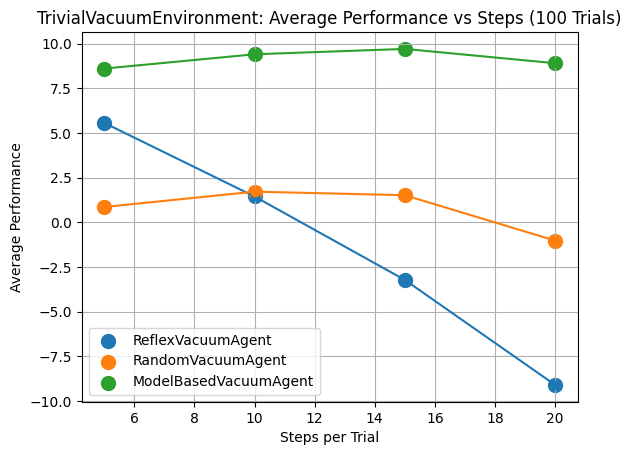

In [3]:
import random
import matplotlib.pyplot as plt


n_trials = 100
step_sizes = [5, 10, 15, 20]

agents = [ReflexVacuumAgent, RandomVacuumAgent, ModelBasedVacuumAgent]
random.seed(0)


environments = [
    TrivialVacuumEnvironment
]



for env in environments:

    print(f"\n===== Environment: {env.__name__} =====")

    all_results = {agent.__name__: [] for agent in agents}

    for steps_per_trial in step_sizes:

        results = compare_agents(
            env, agents, n=n_trials, steps=steps_per_trial
        )

        print(f"\nAverage Performance over {n_trials} trials with {steps_per_trial} steps:")

        for agent_class, avg_score in results:
            print(f"{agent_class.__name__}: {avg_score:.2f}")
            all_results[agent_class.__name__].append(avg_score)

    # Plot results for this environment
    plt.figure()

    for agent_name, scores in all_results.items():
        plt.scatter(step_sizes, scores, label=agent_name, s=100)
        plt.plot(step_sizes, scores, marker='o')

    plt.xlabel("Steps per Trial")
    plt.ylabel("Average Performance")
    plt.title(f"{env.__name__}: Average Performance vs Steps ({n_trials} Trials)")
    plt.legend()
    plt.grid(True)

    plt.show()

#Exercise 2.14
Consider a modified version of the vacuum environment in Exercise 2.10, in which the geography of the environment—its extent, boundaries, and obstacles—is unknown, as is the initial dirt configuration. (The agent can go Up and Down as well as Left and Right.)


## 1 - Can a simple reflex agent be perfectly rational for this environment? Explain.
A simple reflex agent has no memory and so can not be perfectly rational in unknown or partially observable environments.

## 2 - Can a simple reflex agent with a randomized agent function outperform a simple reflex agent? Design such an agent and measure its performance on several environments.

Conceptually, yes, since a simple reflex agent is prone to getting stuck in loops, one that has randomized actions to prevent those loops along with the reflex action could outperform a simple reflex as steps go on, depending on the environment.

The following code cell implements the `RandomizedReflexVacuumAgent` and compares it to the (simple) `ReflexVacuumAgent`. We also implemented a `TrapVacuumEnvironment` where the dirt moves every 2 steps. The output shows that the randomized agent out-performs the simple reflex agent in every trial where there are more than 5 steps.


===== Environment: TrivialVacuumEnvironment =====

Average Performance over 100 trials with 5 steps:
ReflexVacuumAgent: 5.56
RandomizedReflexVacuumAgent: 5.49

Average Performance over 100 trials with 10 steps:
ReflexVacuumAgent: 0.89
RandomizedReflexVacuumAgent: 3.64

Average Performance over 100 trials with 15 steps:
ReflexVacuumAgent: -4.44
RandomizedReflexVacuumAgent: 0.40

Average Performance over 100 trials with 20 steps:
ReflexVacuumAgent: -8.56
RandomizedReflexVacuumAgent: -2.44


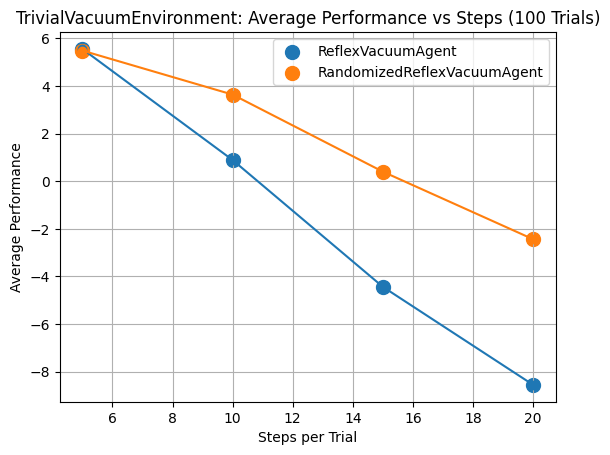


===== Environment: TrapVacuumEnvironment =====

Average Performance over 100 trials with 5 steps:
ReflexVacuumAgent: 1.32
RandomizedReflexVacuumAgent: 5.95

Average Performance over 100 trials with 10 steps:
ReflexVacuumAgent: -1.52
RandomizedReflexVacuumAgent: 3.78

Average Performance over 100 trials with 15 steps:
ReflexVacuumAgent: -6.28
RandomizedReflexVacuumAgent: 0.89

Average Performance over 100 trials with 20 steps:
ReflexVacuumAgent: -9.52
RandomizedReflexVacuumAgent: -2.53


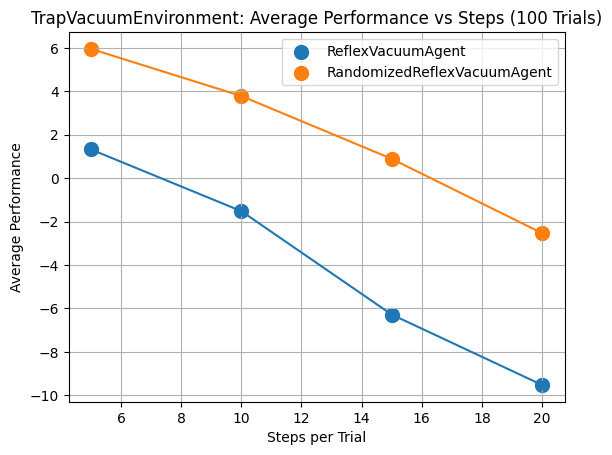

In [4]:
def RandomizedReflexVacuumAgent():
    def program(percept):
        location, status = percept
        if status == "Dirty":
            return "Suck"
        else:
            return random.choice(["Right", "Left", "NoOp"])
    return Agent(program)

class TrapVacuumEnvironment(Environment):
    """
    Environment designed so that a ReflexVacuumAgent gets trapped and misses
    dirt appearing in the other location, while a ReflexRandomAgent can
    outperform it by exploring randomly.
    """

    def __init__(self):
        super().__init__()
        self.status = {
            loc_A: "Dirty",
            loc_B: "Clean",
        }
        self.step_count = 0

    def thing_classes(self):
        return [
            Wall,
            Dirt,
            ReflexVacuumAgent,
            RandomizedReflexVacuumAgent,
        ]

    def percept(self, agent):
        return agent.location, self.status[agent.location]

    def execute_action(self, agent, action):
        self.step_count += 1

        if self.step_count % 2 == 0:
            if self.status[loc_A] == "Clean" and self.status[loc_B] == "Dirty":
                self.status[loc_A] = "Dirty"
                self.status[loc_B] = "Clean"
            elif self.status[loc_B] == "Clean" and self.status[loc_A] == "Dirty":
                self.status[loc_B] = "Dirty"
                self.status[loc_A] = "Clean"

        if action == "Right":
            agent.location = loc_B
            agent.performance -= 1
        elif action == "Left":
            agent.location = loc_A
            agent.performance -= 1
        elif action == "Suck":
            if self.status[agent.location] == "Dirty":
                agent.performance += 10
                self.status[agent.location] = "Clean"

    def default_location(self, thing):
        return random.choice([loc_A, loc_B])

step_sizes = [5, 10, 15, 20]

agents = [ReflexVacuumAgent, RandomizedReflexVacuumAgent]

environments = [
    TrivialVacuumEnvironment,
    TrapVacuumEnvironment,
]

random.seed(0)

for env in environments:

    print(f"\n===== Environment: {env.__name__} =====")

    all_results = {agent.__name__: [] for agent in agents}

    for steps_per_trial in step_sizes:

        results = compare_agents(
            env, agents, n=n_trials, steps=steps_per_trial
        )

        print(f"\nAverage Performance over {n_trials} trials with {steps_per_trial} steps:")

        for agent_class, avg_score in results:
            print(f"{agent_class.__name__}: {avg_score:.2f}")
            all_results[agent_class.__name__].append(avg_score)

    plt.figure()

    for agent_name, scores in all_results.items():
        plt.scatter(step_sizes, scores, label=agent_name, s=100)
        plt.plot(step_sizes, scores, marker='o')

    plt.xlabel("Steps per Trial")
    plt.ylabel("Average Performance")
    plt.title(f"{env.__name__}: Average Performance vs Steps ({n_trials} Trials)")
    plt.legend()
    plt.grid(True)

    plt.show()

## 3- Can you design an environment in which your randomized agent will perform poorly? Show your results.

Yes. A simple enviroment where a the new randomized agent will perform poorly is a long corridor with a `Dirty` cell at the end.

The following code cell implements `CorridorReflexAgent`, a simple reflex agent for this exact enviroment. It also creates `CorridorEnvironment`, the reference enviroment where the randomized agent will perform poorly.

Both agents are ran in said enviroment and compared, and output results show that the simple reflex agent outperforms the randomized reflex agent in this specific enviroment for any case where there are more than 5 steps.


===== Environment: CorridorEnvironment =====

Average Performance over 100 trials with 5 steps:
CorridorReflexAgent: -5.00
RandomizedReflexVacuumAgent: -3.33

Average Performance over 100 trials with 10 steps:
CorridorReflexAgent: 1.00
RandomizedReflexVacuumAgent: -6.80

Average Performance over 100 trials with 15 steps:
CorridorReflexAgent: -4.00
RandomizedReflexVacuumAgent: -10.13

Average Performance over 100 trials with 20 steps:
CorridorReflexAgent: -9.00
RandomizedReflexVacuumAgent: -12.94


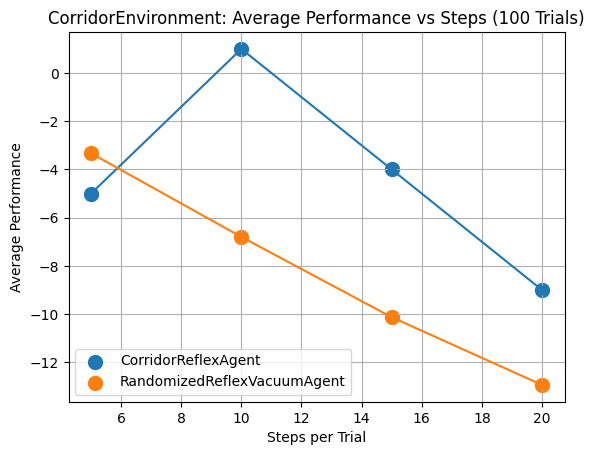

In [5]:
def CorridorReflexAgent():
    def program(percept):
        location, status = percept
        if status == "Dirty":
            return "Suck"
        return "Right"
    return Agent(program)



CORRIDOR_LENGTH = 10

class CorridorEnvironment(Environment):
    """A 10-room corridor. Dirt only at the last room.
    Score: +10 for cleaning the dirt, -1 per move."""

    def __init__(self):
        super().__init__()
        self.length = CORRIDOR_LENGTH
        self.status = {i: ("Dirty" if i == self.length - 1 else "Clean")
                       for i in range(self.length)}

    def percept(self, agent):
        return agent.location, self.status[agent.location]

    def execute_action(self, agent, action):
        loc = agent.location
        if action == "Right":
            agent.location = min(loc + 1, self.length - 1)
            agent.performance -= 1
        elif action == "Left":
            agent.location = max(loc - 1, 0)
            agent.performance -= 1
        elif action == "Suck":
            if self.status[loc] == "Dirty":
                agent.performance += 10
            self.status[loc] = "Clean"

    def default_location(self, thing):
        return 0



n_trials = 100
step_sizes = [5, 10, 15, 20]
agents = [CorridorReflexAgent, RandomizedReflexVacuumAgent]
random.seed(0)

environments = [
    CorridorEnvironment
]

for env in environments:

    print(f"\n===== Environment: {env.__name__} =====")

    all_results = {agent.__name__: [] for agent in agents}

    for steps_per_trial in step_sizes:
        results = compare_agents(
            env, agents, n=n_trials, steps=steps_per_trial
        )

        print(f"\nAverage Performance over {n_trials} trials with {steps_per_trial} steps:")
        for agent_class, avg_score in results:
            print(f"{agent_class.__name__}: {avg_score:.2f}")
            all_results[agent_class.__name__].append(avg_score)

    plt.figure()
    for agent_name, scores in all_results.items():
        plt.scatter(step_sizes, scores, label=agent_name, s=100)
        plt.plot(step_sizes, scores, linestyle='-', marker='o')

    plt.xlabel("Steps per Trial")
    plt.ylabel("Average Performance")
    plt.title(f"{env.__name__}: Average Performance vs Steps ({n_trials} Trials)")
    plt.legend()
    plt.grid(True)
    plt.show()

## 4 - Can a reflex agent with state outperform a simple reflex agent? Design such an agent and measure its performance. Can you design a rational agent of this type?

Yes, as reference in the code (and textbook), a reflex agent with state is known as a model based agent, and this is implemented within `agents.py` in the Berkley repository. In the experiments main code [Jump to Section](#main-code-for-experiment), the model based is seen outperforming the completely randomized agent tand the simple reflex agent in all scenarios.

# Results and Discussions of the Main EXperiment
After running the different trials (of the main code) all the results were inserted into the following table:

| Steps | ReflexVacuumAgent | RandomVacuumAgent | ModelBasedVacuumAgent |
| ----- | ----------------- | ----------------- | --------------------- |
| 5     | 5.56              | 0.85              | 8.60                  |
| 10    | 1.44              | 1.71              | 9.40                  |
| 15    | -3.23             | 1.51              | 9.70                  |
| 20    | -9.11             | -1.03             | 8.90                  |

The results showed the expected behavior for each agent, according to what textbook (Artificial Intelligence: A Modern Approach) and the course material.

* The **ReflexVacuumAgent** performs well in short trials (5 steps: 5.56) due to its simple deterministic strategy of checking and cleaning cells sequentially. However, its performance drops sharply in longer trials, reaching negative values at 15 and 20 steps, because it can get trapped in repetitive movements without a NoOp action. This behavior is expected, as stated by the book: "Infinite loops are often unavoidable for simple reflex agents operating in partially observable environments”

* The **RandomVacuumAgent** starts with low scores (0.85 at 5 steps) but remains relatively stable as steps increase. This stability arises from its stochastic behavior: the agent selects actions at random, including moving, cleaning, or doing nothing. Its random actions prevent looping, outperforming the **ReflexVacuumAgent** in longer trials, but lack of planning keeps its scores modest.

* The **ModelBasedVacuumAgent** consistently achieves the highest scores (8.60–9.70), thanks to its internal model that tracks which cells are clean, allowing efficient planning and avoiding wasted actions. This high-performance outcome is expected, as stated by the textbook this "The most effective way to handle partial observability"

# Defining PEAS

As our code uses the Berkeley AIMA `agents.py` implementation, much of the environment and agent infrastructure is already provided. However, the following describes how the **Performance measure, Environment, Actuators, and Sensors (PEAS)**.

<br>

## P — Performance Measure

The performance of each agent is measured during each simulation run.  
The simulator keeps track of the score throughout the experiment.

The performance function follows the structure described in the assignment and AIMA vacuum world:

- **+10 for each cleaned square**
- **−1 for each step performed** (penalizes unnecessary movement).
- The environment accumulates this score during the simulation.

<br>

## E — Environment

The experiments use the **Vacuum Environment model from the Berkeley AIMA implementation**, which defines the world independently from the agent logic.

### Spatial Structure
- The base environment is the **two-location vacuum world** (locations **A** and **B**) implemented in `TrivialVacuumEnvironment`.
- Each location can independently contain dirt.

Additionally, we implemented a **trap vacuum enviroment** where the dirt changes location every 2 steps if not cleaned, this was done when evaluating `RandomizedReflexVacuumAgent`, and a **corridor-style environment scenario** when evaluating the `CorridorReflexAgent`, which represents a longer linear space where the agent continuously moves right.

### Dirt Distribution
- Dirt is initially distributed randomly in the environment.
- Each square can be either `Clean` or `Dirty`.
- In `TrapVacuumEnvironment` the dirty changes cell every 2 steps (if not cleaned).

### Agent Location
- The agent is placed in one of the locations at the start of the simulation.
- The environment maintains the agent’s current position.

### State-transition dynamics.
- The enviroment updates `Dirty` cells to `Clean` whenever an agent performs `Sucks` on a `Dirty` Cell
- The `TrapVacuumEnvironment` moves the `Dirt` to a different cell whenever 2 steps of the simulation has passed and the `Dirt` has not been cleaned.

<br>

## A — Actuators

The main action set supported by the vacuum environment is:

- **Left** – move the agent to the left location
- **Right** – move the agent to the right location
- **Suck** – clean the dirt at the current location
- **NoOp** – perform no action

Different agents use **different subsets of these actions**:

| Agent | Actions Used |
|------|--------------|
| `ReflexVacuumAgent` | `Left`, `Right`, `Suck` |
| `RandomVacuumAgent` | `Left`, `Right`, `Suck`, `NoOp`
| `ModelBasedVacuumAgent` | `Left`, `Right`, `Suck`, `NoOp`|
| `RandomizedReflexVacuumAgent` | `Left`, `Right`, `Suck` (random movement when clean) |
| `CorridorReflexAgent` | `Right`, `Suck` |

<br>

## S — Sensors

Sensors provide the **percept** that the environment sends to the agent at each time step.

In the Berkeley vacuum environment, the percept is defined as:

- **location** → the agent’s current position (e.g., `A` or `B`)
- **status** → whether the current square is `"Clean"` or `"Dirty"`

Different agents use different sensors:

| Agent | Sensor Information Used |
|------|-------------------------|
| `ReflexVacuumAgent` | Uses `(location, status)` to decide whether to clean or move |
| `RandomVacuumAgent` | Uses random actions |
| `ModelBasedVacuumAgent` | Uses `(location, status)` and internal state about both squares |
| `RandomizedReflexVacuumAgent` | Uses `(location, status)` with randomized movement policy |
| `CorridorReflexAgent` | Uses `(status)`, no location since it always moves right.
